# MGSIM End-to-End: Data → Ensembles → Comparison Figure

This notebook runs the full MGSIM pipeline from the input
flight-line data to an ensemble comparison figure.

- **Section 1** builds each interpolation from the same data: minimum curvature, kriging, an SGSIM
  ensemble, and an MGSIM ensemble.
- **Section 2** assembles a comparison figure from those results.

## The two knobs

Set these in the next cell:

- **`N_REALIZATIONS`** — ensemble size. Set small (2) so a first run finishes in ~15 minutes;
  try 10 for a meaningful comparison (~1 hour), and paper-scale runs use **1000**. Ensemble
  means/variances converge as N grows.
- **`SEED`** — realization $i$ of each ensemble is seeded with `SEED + i`, so the same settings
  regenerate the *identical* ensemble every time on your machine, and results are independent of run
  order or chunking.



In [10]:
# ----------------------------- THE TWO KNOBS --------------------------------
N_REALIZATIONS = 2      # ensemble size (try 10; paper: 1000)
SEED           = 0      # realization i is seeded with SEED + i

# ----------------------------- setup -----------------------------------------
import json, time, io, contextlib
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.preprocessing import QuantileTransformer
import skgstat as skg
import gstatsim as gs

# Paths — relative to the repo (this notebook runs from demos/)
REPO   = Path.cwd().resolve().parent
CONFIG = REPO / 'config' / 'config_mgsim_clusteriso_medium.json'
GT_CSV = REPO / 'demos' / 'data' / 'gt_xyvc.csv'
OUT    = REPO / 'demos' / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)

from multigrid_sgsim import geosoft_cmap_k65

# Shared simulation constants (gaussian variograms, maxlag=40, n_lags=40, k=10, radius=40)
ROWS, COLS   = 50, 200
K_NEIGHBORS  = 10
SEARCH_RAD   = 40
MAXLAG, N_LAGS, VGM_MODEL = 40, 40, 'gaussian'
VMIN, VMAX   = -1000, 1500

geosoft_cmap = geosoft_cmap_k65()
ls = LightSource(azdeg=315, altdeg=45)

def shade(mat, cmap=geosoft_cmap, vmin=VMIN, vmax=VMAX):
    return ls.shade(mat, cmap=cmap, blend_mode='soft', vmin=vmin, vmax=vmax)

def show_fields(panels, height=2.4):
    """panels: list of (2D array, title[, cmap, vmin, vmax]) — stacked hillshaded maps."""
    fig, axes = plt.subplots(len(panels), 1, figsize=(15, height * len(panels)), squeeze=False)
    for ax, p in zip(axes[:, 0], panels):
        mat, title = p[0], p[1]
        cmap, vmn, vmx = (p[2], p[3], p[4]) if len(p) > 2 else (geosoft_cmap, VMIN, VMAX)
        ax.imshow(shade(mat, cmap, vmn, vmx), origin='lower', extent=extent, aspect='equal')
        ax.set_title(title, fontsize=13); ax.set_ylabel('y [px]')
    axes[-1, 0].set_xlabel('x [px]')
    plt.tight_layout(); plt.show()

def rmse(pred):
    return float(np.sqrt(np.nanmean((pred - gt) ** 2)))

print(f'N_REALIZATIONS = {N_REALIZATIONS}, SEED = {SEED}')
print(f'numpy {np.__version__}, gstatsim installed, skgstat {skg.__version__}')


N_REALIZATIONS = 2, SEED = 0
numpy 2.3.5, gstatsim installed, skgstat 1.0.23


## Section 1 — Building the interpolations

### 1.0 The data

One synthetic magnetic (RMI) grid of 50 × 200 px is the **ground truth**. The observations are
flight lines sampled from it every 6 px — 1,667 points out of 10,000. Every method below sees only the
flight lines.


10000 grid nodes, 1667 flight-line observations (spacing = 6 px)


,x,y,cluster,trend,value,set,residual
0,0.0,0.0,0,275.086352,474.224075,1,199.137723
1,1.0,0.0,0,259.738908,NaN,0,NaN
2,2.0,0.0,0,243.653842,NaN,0,NaN


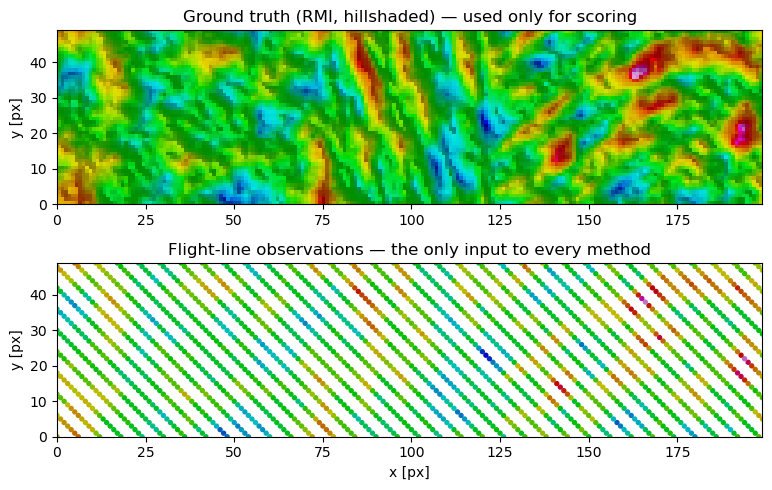

In [11]:
with open(CONFIG) as f:
    cfg = json.load(f)
df_data = pd.read_csv(REPO / cfg['data_file'])
gt = pd.read_csv(GT_CSV)['val'].values.reshape(ROWS, COLS)

# sanity checks: config and dataset describe the same grid
assert tuple(cfg['grid_shape']) == (ROWS, COLS)
assert len(df_data) == ROWS * COLS
assert {'x', 'y', 'value', 'trend', 'set', 'cluster'} <= set(df_data.columns)

obs = df_data[df_data['set'] == 1]
x_coords = np.arange(COLS, dtype=float)
y_coords = np.arange(ROWS, dtype=float)
xx, yy = np.meshgrid(x_coords, y_coords)
pred_grid = np.column_stack([xx.ravel(), yy.ravel()])   # the 10,000 nodes to interpolate
extent = [0, COLS - 1, 0, ROWS - 1]

print(f'{len(df_data)} grid nodes, {len(obs)} flight-line observations (spacing = 6 px)')
display(df_data.head(3))

fig, axes = plt.subplots(2, 1, figsize=(15, 5))
axes[0].imshow(shade(gt), origin='lower', extent=extent, aspect='equal')
axes[0].set_title('Ground truth (RMI, hillshaded) — used only for scoring'); axes[0].set_ylabel('y [px]')
axes[1].scatter(obs['x'], obs['y'], c=obs['value'], cmap=geosoft_cmap, vmin=VMIN, vmax=VMAX, s=8)
axes[1].set_xlim(extent[0], extent[1]); axes[1].set_ylim(extent[2], extent[3])
axes[1].set_aspect('equal'); axes[1].set_title('Flight-line observations — the only input to every method')
axes[1].set_xlabel('x [px]'); axes[1].set_ylabel('y [px]')
plt.tight_layout(); plt.show()


### 1.1 Minimum curvature

The industry-standard deterministic gridding: the smoothest surface (minimized second derivative)
passing through the data. Fast and artifact-light — but it produces a single map with **no uncertainty
quantification**, which is the gap the paper addresses. We use GMT's `surface` (tension 0) when `pygmt`
is available — the same tool as the paper's Figure 1c — and otherwise scipy's thin-plate spline, the
equivalent zero-tension minimum-curvature (biharmonic) interpolant.


scipy thin-plate spline (biharmonic = zero-tension min curvature)  [0.2 s]
RMSE vs ground truth: 84.8 [nT]


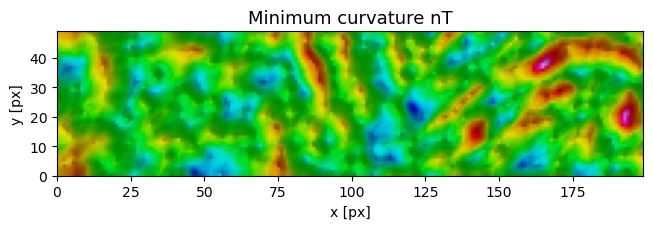

In [12]:
t0 = time.time()
try:
    import pygmt
    grd = pygmt.surface(x=obs['x'], y=obs['y'], z=obs['value'],
                        region=[0, COLS - 1, 0, ROWS - 1], spacing=1, tension=0)
    mincurve = np.asarray(grd.sortby('y'))
    method_mc = 'pygmt.surface (tension=0)'
except ImportError:
    from scipy.interpolate import RBFInterpolator
    rbf = RBFInterpolator(obs[['x', 'y']].values, obs['value'].values, kernel='thin_plate_spline')
    mincurve = rbf(pred_grid).reshape(ROWS, COLS)
    method_mc = 'scipy thin-plate spline (biharmonic = zero-tension min curvature)'

rmse_mc = rmse(mincurve)
print(f'{method_mc}  [{time.time()-t0:.1f} s]')
print(f'RMSE vs ground truth: {rmse_mc:.1f} [nT]')
show_fields([(mincurve, f'Minimum curvature nT')])


### 1.2 Kriging

Ordinary kriging: at each node, the best linear unbiased estimate from the `k=10` nearest observations,
weighted by a variogram model fitted to the data. Deterministic — rerunning always gives the identical
result — and it produces a variance map alongside the prediction. Kriging here runs on the raw values,
so its variance is in nT² and directly comparable to the ensemble variances later in the notebook.


Fitted variogram: range=12.35, sill=128041.9, nugget=0.0


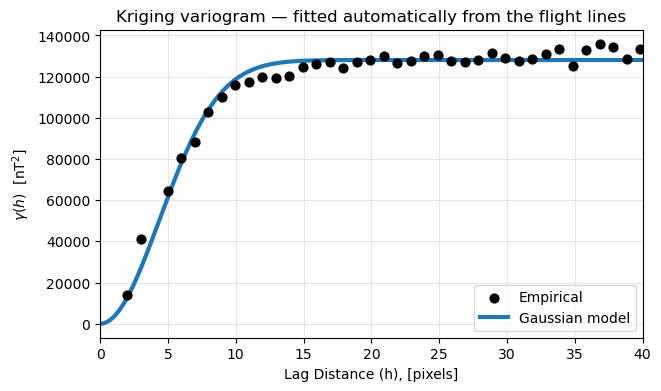

Kriging done [26 s]
RMSE vs ground truth: 96.1 nT


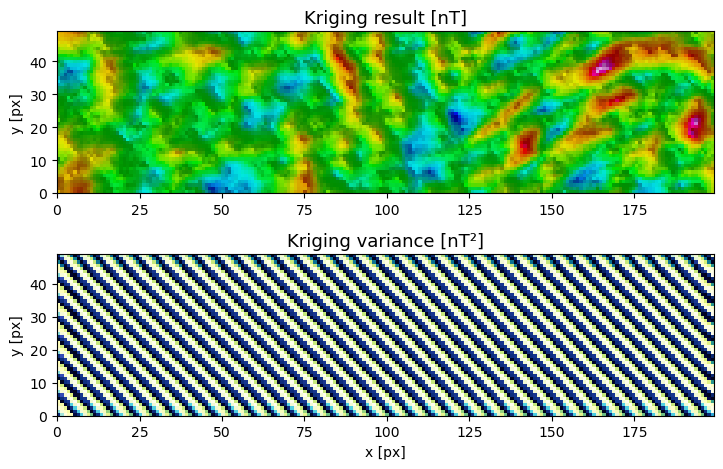

In [13]:
df_obs_kr = obs.rename(columns={'value': 'val'})[['x', 'y', 'val']].copy()

# Variogram fitted to the observations
V_kr = skg.Variogram(df_obs_kr[['x', 'y']].values, df_obs_kr['val'].values,
                     maxlag=MAXLAG, n_lags=N_LAGS, model=VGM_MODEL)
rng_p, sill_p, nug_p = V_kr.parameters
vario_kr = [0.0, nug_p, rng_p, rng_p, sill_p, VGM_MODEL.capitalize()]
print(f'Fitted variogram: range={rng_p:.2f}, sill={sill_p:.1f}, nugget={nug_p:.1f}')

h = np.linspace(0, MAXLAG, 200)
plt.figure(figsize=(7, 4))
plt.scatter(V_kr.bins, V_kr.experimental, c='black', s=40, zorder=3, label='Empirical')
plt.plot(h, V_kr.transform(h), color='C0', lw=3, label='Gaussian model')
plt.xlabel('Lag Distance (h), [pixels]'); plt.ylabel(r'$\gamma(h)$  [nT$^2$]')
plt.title('Kriging variogram — fitted automatically from the flight lines')
plt.xlim(0, MAXLAG); plt.legend(); plt.grid(alpha=0.3); plt.show()

t0 = time.time()
pred_kr, var_kr = gs.Interpolation.okrige(
    pred_grid, df_obs_kr, 'x', 'y', 'val', K_NEIGHBORS, vario_kr, SEARCH_RAD, quiet=True)
krig     = pred_kr.reshape(ROWS, COLS)
krig_var = var_kr.reshape(ROWS, COLS)
rmse_kr  = rmse(krig)
print(f'Kriging done [{time.time()-t0:.0f} s]')
print(f'RMSE vs ground truth: {rmse_kr:.1f} nT')
show_fields([(krig, f'Kriging result [nT]'),
             (krig_var, 'Kriging variance [nT²]',
              plt.cm.YlGnBu_r, 0, float(np.percentile(krig_var, 99)))])


### 1.3 SGSIM — sequential Gaussian simulation (standard workflow)

Where kriging returns one smoothed map, SGSIM returns an **ensemble of equally probable maps**: it
visits the grid in a random order and, at each node, draws from the local kriging distribution instead
of taking its mean, conditioning later nodes on earlier draws. Each realization has realistic texture
(no kriging over-smoothing), and the pixel-wise spread across realizations quantifies uncertainty.

The standard workflow: (1) normal-score transform (NST) the observed values to a Gaussian
distribution, (2) fit variogram to the transformed values, (3) simulate with seed
`SEED + i` per realization, (4) back-transform.


Fitted variogram (NST values): range=13.06, sill=0.989, nugget=0.000


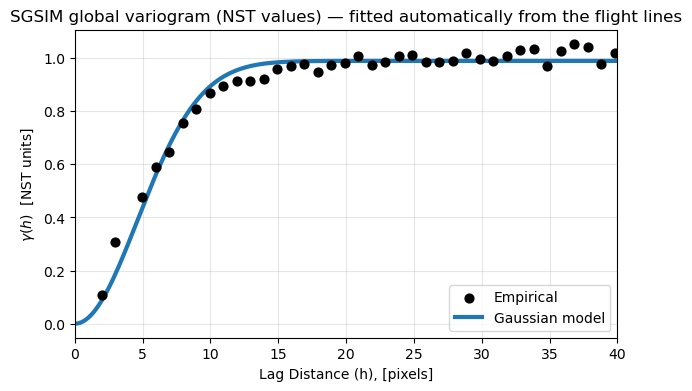

  SGSIM realization 1/2 (seed 0)  [29 s]
  SGSIM realization 2/2 (seed 1)  [28 s]

Ensemble mean RMSE vs ground truth: 122.7 nT


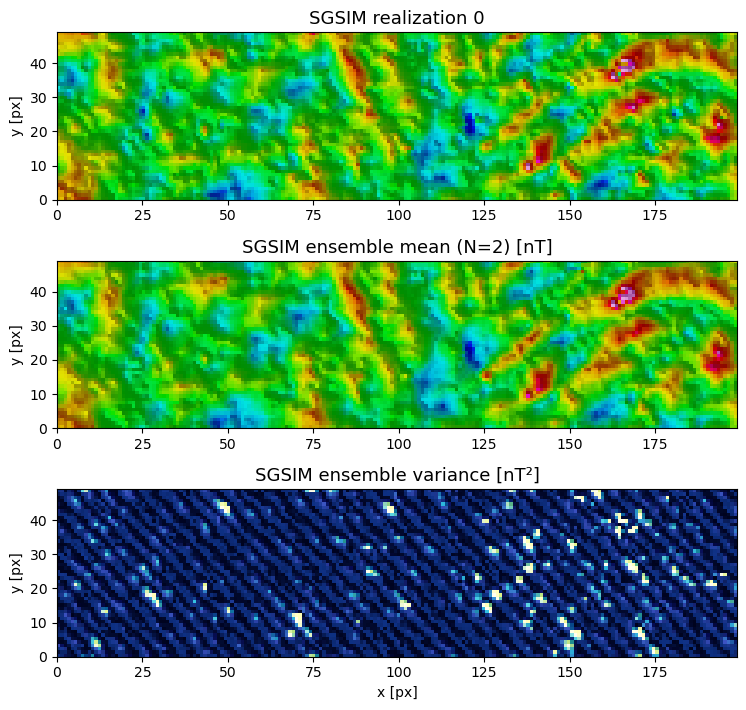

In [14]:
df_obs_sg = obs.rename(columns={'value': 'val'})[['x', 'y', 'val']].copy()

# (1) Normal-score transform
nst = QuantileTransformer(output_distribution='normal',
                          n_quantiles=min(1000, len(df_obs_sg))).fit(df_obs_sg[['val']].values)
df_obs_sg['nval'] = nst.transform(df_obs_sg[['val']].values).ravel()

# (2) One global variogram, fitted to the NST values (sill ~ 1 by construction)
V = skg.Variogram(df_obs_sg[['x', 'y']].values, df_obs_sg['nval'].values,
                  maxlag=MAXLAG, n_lags=N_LAGS, model=VGM_MODEL)
rng_n, sill_n, nug_n = V.parameters
vario_nst = [0.0, nug_n, rng_n, rng_n, sill_n, VGM_MODEL.capitalize()]
print(f'Fitted variogram (NST values): range={rng_n:.2f}, sill={sill_n:.3f}, nugget={nug_n:.3f}')

h = np.linspace(0, MAXLAG, 200)
plt.figure(figsize=(7, 4))
plt.scatter(V.bins, V.experimental, c='black', s=40, zorder=3, label='Empirical')
plt.plot(h, V.transform(h), color='C0', lw=3, label='Gaussian model')
plt.xlabel('Lag Distance (h), [pixels]'); plt.ylabel(r'$\gamma(h)$  [NST units]')
plt.title('SGSIM global variogram (NST values) — fitted automatically from the flight lines')
plt.xlim(0, MAXLAG); plt.legend(); plt.grid(alpha=0.3); plt.show()

# (3) simulate + (4) back-transform, one seeded realization at a time
sgsim_real = np.full((N_REALIZATIONS, ROWS, COLS), np.nan, dtype=np.float32)
for i in range(N_REALIZATIONS):
    t0 = time.time()
    rng = np.random.default_rng(SEED + i)
    sim = gs.Interpolation.okrige_sgs(pred_grid, df_obs_sg, 'x', 'y', 'nval',
                                      K_NEIGHBORS, vario_nst, SEARCH_RAD, seed=rng, quiet=True)
    sgsim_real[i] = nst.inverse_transform(sim.reshape(-1, 1)).ravel().reshape(ROWS, COLS)
    print(f'  SGSIM realization {i + 1}/{N_REALIZATIONS} (seed {SEED + i})  [{time.time()-t0:.0f} s]')

sgsim_mean, sgsim_var = sgsim_real.mean(axis=0), sgsim_real.var(axis=0)
rmse_sg = rmse(sgsim_mean)
print(f'\nEnsemble mean RMSE vs ground truth: {rmse_sg:.1f} nT')
show_fields([(sgsim_real[0], 'SGSIM realization 0'),
             (sgsim_mean, f'SGSIM ensemble mean (N={N_REALIZATIONS}) [nT]'),
             (sgsim_var, 'SGSIM ensemble variance [nT²]',
              plt.cm.YlGnBu_r, 0, float(np.percentile(sgsim_var, 99)))])


### 1.4 MGSIM — multigrid simulation (the paper's method)

MGSIM upgrades SGSIM in two ways, both visible in its inputs:

1. **Trend + residual decomposition with subregions.** The field is modeled as
   $z(x) = m(x) + r(x)$: a smooth trend $m_0$ fitted to the data, plus residuals simulated with a
   **separate variogram per clustered subregion** (4 here, found by automated segmentation) — so
   non-stationarity is respected instead of averaged away by one global variogram.
2. **Multigrid iteration.** Each realization runs SGS repeatedly, conditioning on subsampled residuals
   at coarse-to-fine spacings (`mg_resols = [20, 15, 10, 5, 4, 3, 2, 1]`), updating the trend after
   each pass.

Everything MGSIM consumes is frozen in one config (dataset, trend, clusters, per-cluster variograms,
schedule) — here `config/config_mgsim_clusteriso_medium.json`. The per-subregion Gaussian
variograms are fitted to the **normal-score-transformed, trend-subtracted residuals** — the field MGSIM
actually simulates.

MGSIM has two stochastic components — the SGS engine (gstatsim's `cluster_sgs`) and the residual
subsampler — and `mgsim(seed=SEED + i)` threads a single per-realization generator through both,
making the ensemble exactly repeatable.


mg_resols = [20, 15, 10, 5, 4, 3, 2, 1]
simulation kwargs = {'xx': 'x', 'yy': 'y', 'zz': 'Nresidual', 'kk': 'cluster', 'num_points': 10, 'radius': 40, 'sgs_or_krige': 'sgs', 'clip_nst': True, 'clip_percentile': 98.0}
trend provenance  = {'trend_method': 'RBF smoothing (trendmaking.make_trend)', 'smoothing': 1000.0, 'linespacing': 20, 'random_state': 0, 'source_flightlines': 'demos/data/fl_xyvc.csv', 'note': 'trend values stored per grid point in the data CSV `trend` column; make_trend(random_state=0) regenerates them exactly'}


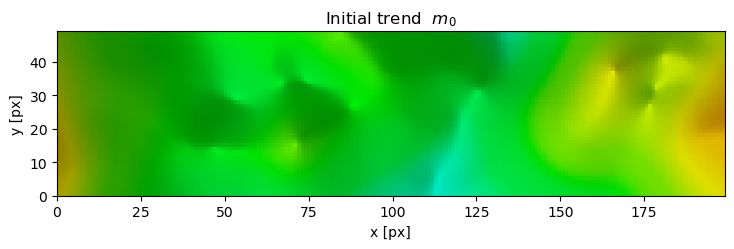

In [15]:
mg_resols = cfg['mg_resols']
mgsim_kwargs = cfg['mgsim_kwargs']
n_clusters = len(cfg['variograms_list'])
print(f"mg_resols = {mg_resols}")
print(f"simulation kwargs = {mgsim_kwargs}")
print(f"trend provenance  = {cfg['metadata'].get('trend')}")

trend = df_data['trend'].values.reshape(ROWS, COLS)
fig, ax1 = plt.subplots(figsize=(15, 2.6))
ax1.imshow(shade(trend), origin='lower', extent=extent, aspect='equal')
ax1.set_title('Initial trend  $m_0$')
ax1.set_xlabel('x [px]'); ax1.set_ylabel('y [px]')
plt.tight_layout(); plt.show()


cluster  refit range   frozen range   refit sill    frozen sill   match
0        12.4494       12.4494        0.7026        0.7026        EXACT
1        10.4703       10.4703        0.7148        0.7148        EXACT
2        10.2728       10.2728        1.1089        1.1089        EXACT
3        10.3182       10.3182        1.6485        1.6485        EXACT


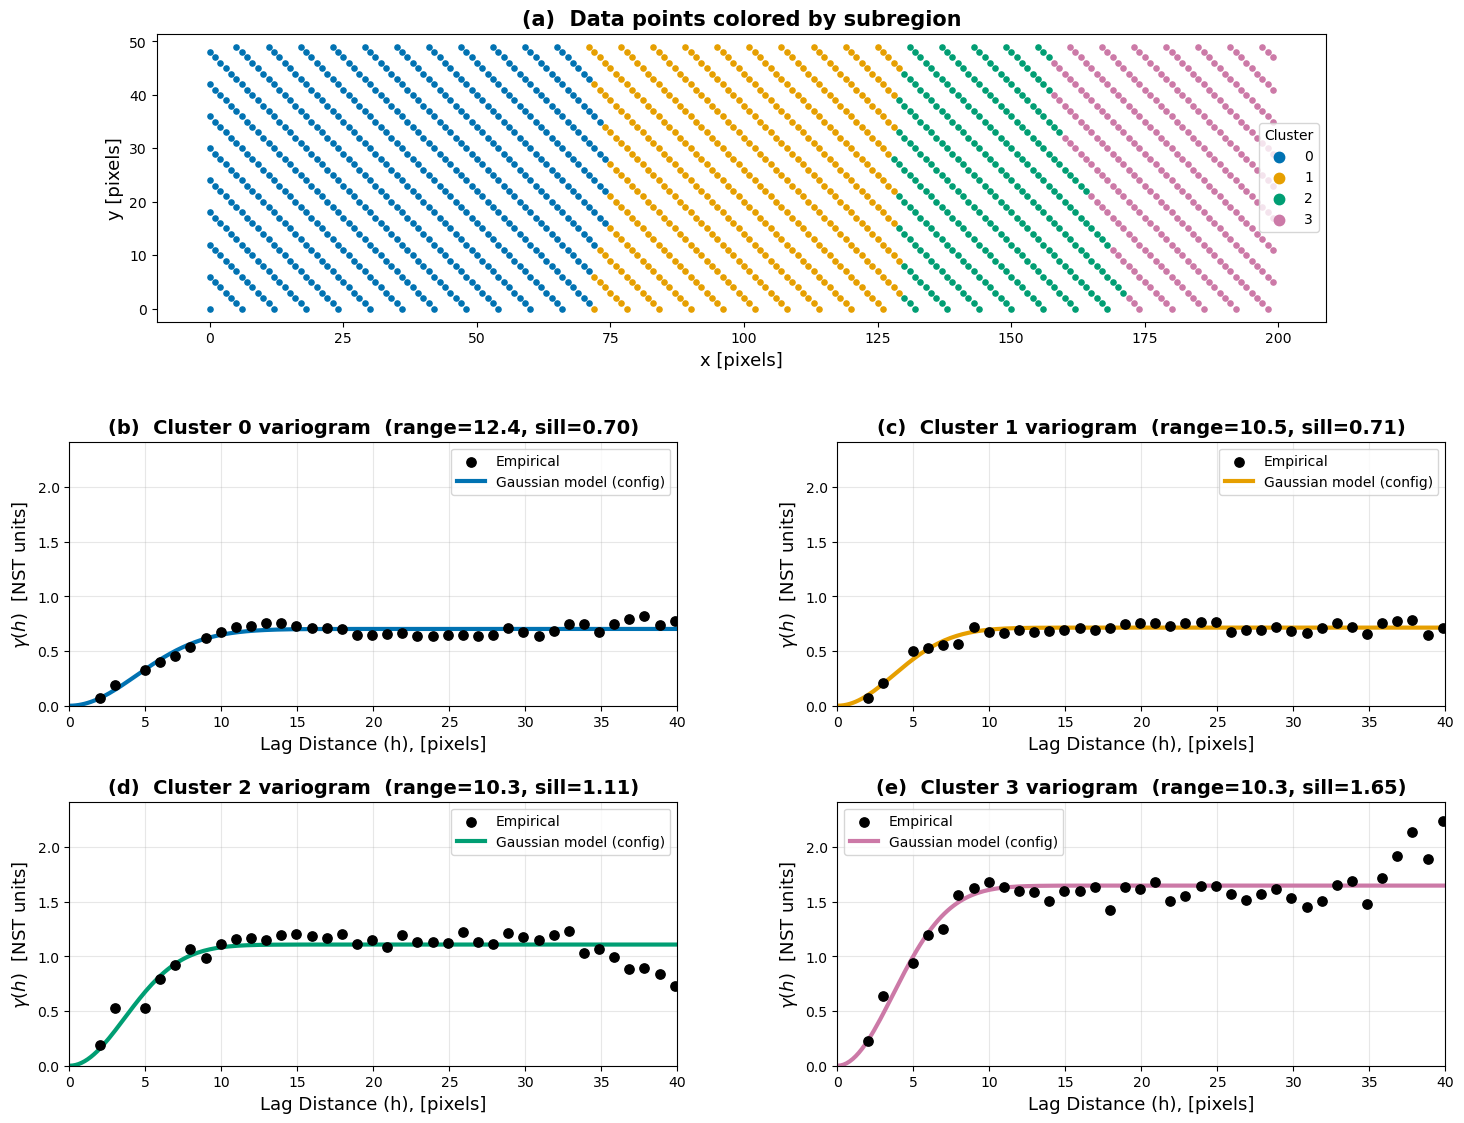

In [16]:
# The per-cluster variograms: (a) subregions, (b-e) empirical + config model.
# The variograms are fitted to the NST-transformed, trend-subtracted residuals — the field MGSIM
# simulates. The empirical points are recomputed here from the shipped data with the same NST, and the
# printed table verifies the refit reproduces the config parameters exactly.
from multigrid_sgsim import cluster_variogram
from skgstat import models as skmodels

obs_c = obs.copy(); obs_c['cluster'] = obs_c['cluster'].astype(int)

# Same NST as the production pipeline: fitted on the observation residuals (value - trend)
res_obs = (obs_c['value'] - obs_c['trend']).values
res_fin = res_obs[np.isfinite(res_obs)].reshape(-1, 1)
nst_mg = QuantileTransformer(output_distribution='normal',
                             n_quantiles=min(1000, len(res_fin))).fit(res_fin)
obs_c['Nresidual'] = nst_mg.transform(res_obs.reshape(-1, 1)).ravel()
cluster_colors = {0: '#0072B2', 1: '#E69F00', 2: '#009E73', 3: '#CC79A7'}   # Wong palette, as Fig 3

fig = plt.figure(figsize=(16, 12))
ax_a = fig.add_axes([0.08, 0.68, 0.84, 0.24])
for ci in range(n_clusters):
    m = obs_c['cluster'] == ci
    ax_a.scatter(obs_c.loc[m, 'x'], obs_c.loc[m, 'y'], c=cluster_colors[ci], s=14, label=f'{ci}',
                 rasterized=True)
ax_a.set_xlabel('x [pixels]', fontsize=13); ax_a.set_ylabel('y [pixels]', fontsize=13)
ax_a.set_title('(a)  Data points colored by subregion', fontsize=15, fontweight='bold')
ax_a.set_aspect('equal'); ax_a.legend(title='Cluster', markerscale=2, fontsize=10)

positions = [[0.08, 0.36, 0.38, 0.22], [0.56, 0.36, 0.38, 0.22],
             [0.08, 0.06, 0.38, 0.22], [0.56, 0.06, 0.38, 0.22]]
panel_labels = ['(b)', '(c)', '(d)', '(e)']
h = np.linspace(0, MAXLAG, 200)

# Fit all four empirical variograms first, so the panels can share one y-scale
V_emp = [cluster_variogram(obs_c, 'Nresidual', ci, MAXLAG, N_LAGS, VGM_MODEL) for ci in range(n_clusters)]
y_max = 1.08 * max(max(np.nanmax(V.experimental) for V in V_emp),
                   max(v[4] for v in cfg['variograms_list']))

print(f"{'cluster':<8} {'refit range':<13} {'frozen range':<14} {'refit sill':<13} {'frozen sill':<13} match")
for ci, frozen in enumerate(cfg['variograms_list']):
    V_c = V_emp[ci]
    r_c, s_c, n_c = V_c.parameters
    az, nug_f, r_f, _rf, s_f, mdl = frozen
    ok = abs(r_c - r_f) < 1e-3 and abs(s_c - s_f) < 1e-3
    print(f'{ci:<8} {r_c:<13.4f} {r_f:<14.4f} {s_c:<13.4f} {s_f:<13.4f} {"EXACT" if ok else "DIFFERS"}')
    ax = fig.add_axes(positions[ci])
    ax.scatter(V_c.bins, V_c.experimental, c='black', s=45, zorder=3, label='Empirical')
    ax.plot(h, skmodels.gaussian(h, r_f, s_f, nug_f), color=cluster_colors[ci], lw=3,
            label='Gaussian model (config)')
    ax.set_xlabel('Lag Distance (h), [pixels]', fontsize=13)
    ax.set_ylabel(r'$\gamma(h)$  [NST units]', fontsize=13)
    ax.set_title(f'{panel_labels[ci]}  Cluster {ci} variogram  (range={r_f:.1f}, sill={s_f:.2f})',
                 fontsize=14, fontweight='bold')
    ax.set_xlim(0, MAXLAG); ax.set_ylim(0, y_max)   # shared y-scale across all four panels
    ax.grid(alpha=0.3); ax.legend(fontsize=10)
plt.show()


  MGSIM realization 1/2 (seed 0, 8 multigrid passes)  [269 s]
  MGSIM realization 2/2 (seed 1, 8 multigrid passes)  [270 s]

Conditioning at the 1667 observation nodes: max|sim - data| = 5.2e-05 nT
Ensemble mean RMSE vs ground truth: 150.6 nT


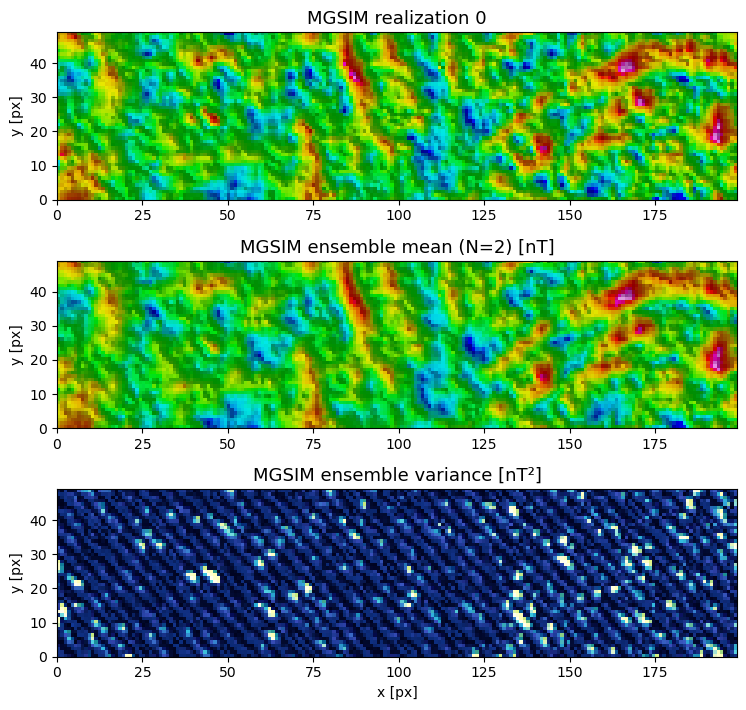

In [17]:
# The config supplies the multigrid schedule and simulation kwargs; nst_mg (previous cell) is the
# normal-score transform of the observation residuals. mgsim(seed=SEED + i) makes realization i
# exactly repeatable.
from multigrid_sgsim import mgsim

df_gamma = pd.DataFrame({'Variogram': cfg['variograms_list']})

mgsim_real = np.full((N_REALIZATIONS, ROWS, COLS), np.nan, dtype=np.float32)
for i in range(N_REALIZATIONS):
    t0 = time.time()
    with contextlib.redirect_stdout(io.StringIO()):     # silence per-iteration prints
        df_out = mgsim(mg_resols=mg_resols, df_xyvtcs=df_data.copy(), df_gamma=df_gamma,
                       nst_trans=nst_mg, seed=SEED + i, **mgsim_kwargs)
    mgsim_real[i] = df_out['newtrend'].values.astype(np.float32).reshape(ROWS, COLS)
    print(f'  MGSIM realization {i + 1}/{N_REALIZATIONS} (seed {SEED + i}, '
          f'{len(mg_resols)} multigrid passes)  [{time.time()-t0:.0f} s]')

mgsim_mean, mgsim_var = mgsim_real.mean(axis=0), mgsim_real.var(axis=0)
rmse_mg = rmse(mgsim_mean)

# Conditioning check: every realization returns the measured value on the flight lines
cond = max(float(np.nanmax(np.abs(mgsim_real[i].reshape(-1)[df_data['set'] == 1]
                                  - obs['value'].values))) for i in range(N_REALIZATIONS))
print(f'\nConditioning at the {len(obs)} observation nodes: max|sim - data| = {cond:.2g} nT')
print(f'Ensemble mean RMSE vs ground truth: {rmse_mg:.1f} nT')
show_fields([(mgsim_real[0], 'MGSIM realization 0'),
             (mgsim_mean, f'MGSIM ensemble mean (N={N_REALIZATIONS}) [nT]'),
             (mgsim_var, 'MGSIM ensemble variance [nT²]',
              plt.cm.YlGnBu_r, 0, float(np.percentile(mgsim_var, 99)))])


## Section 2 — Assembling the comparison figure

Everything the figure needs now exists in memory: the SGSIM ensemble (panels a, c, h), the MGSIM
ensemble (panels b, d, f), and the §1.2 kriging prediction and variance (panels e, g). All three
variance panels share one nT² colorbar, and the kriging panels both come from the single §1.2 kriging
call — the variance shown is the variance of exactly the interpolation shown.

| Row | Left | Right |
|---|---|---|
| 1 | (a) SGSIM realization examples | (b) MGSIM realization examples |
| 2 | (c) SGSIM ensemble mean | (d) MGSIM ensemble mean |
| 3 | (e) Kriging result | (f) MGSIM ensemble variance |
| 4 | (g) Kriging variance | (h) SGSIM ensemble variance |

The shared variance colorbar spans the 99th percentile across all three variance fields; at small N
the ensemble panels show the same structure with visible sampling noise.


In [18]:
# Package the fresh ensembles the way the figure code expects, and save them for reuse
coords = {'realization': np.arange(N_REALIZATIONS), 'y': y_coords, 'x': x_coords}
ds_sgsim = xr.Dataset({'simulated': (('realization', 'y', 'x'), sgsim_real)}, coords=coords)
ds_mgsim = xr.Dataset({'simulated': (('realization', 'y', 'x'), mgsim_real)}, coords=coords)
ds_sgsim.to_netcdf(OUT / f'sgsim_realizations_{SEED}_{SEED + N_REALIZATIONS}.nc')
ds_mgsim.to_netcdf(OUT / f'mgsim_realizations_{SEED}_{SEED + N_REALIZATIONS}.nc')
print('Ensembles saved to', OUT)


Ensembles saved to /Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/demos/outputs


Variance scale: [0, 113035] nT²  (99th percentile across all three methods)
Saved: /Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/demos/outputs/ensemble_comparison_N2.png


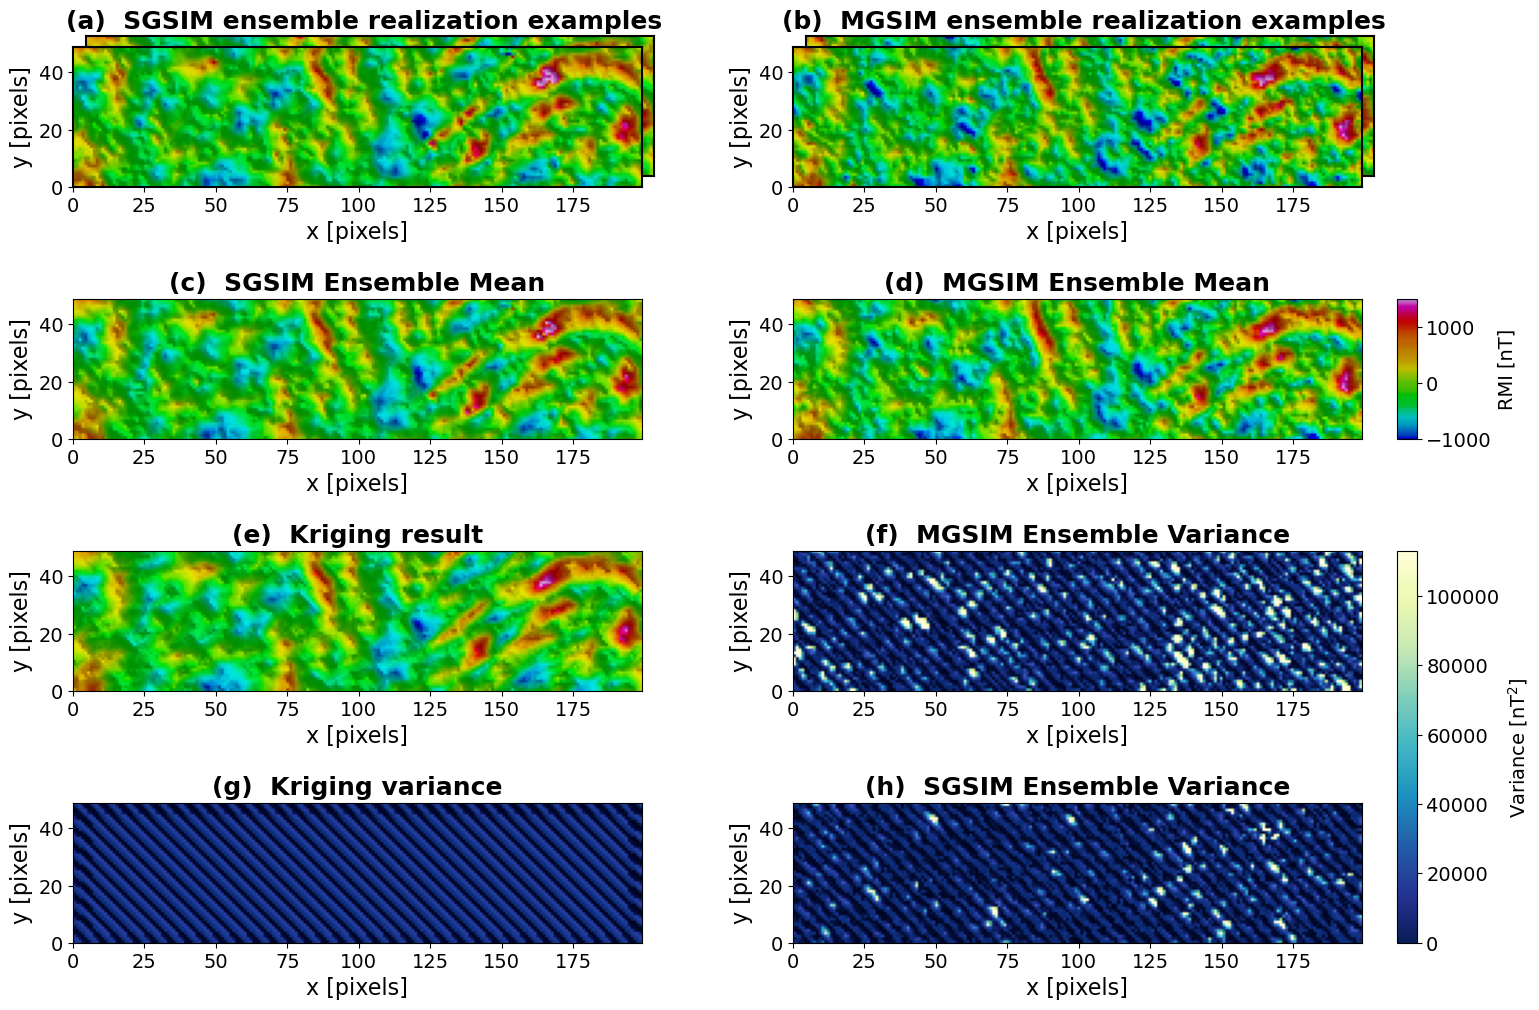

In [19]:
## ENSEMBLE COMPARISON FIGURE: 4-row layout
## Row 1 (top): SGSIM realization stacks | MGSIM realization stacks
## Row 2:       SGSIM mean              | MGSIM mean
## Row 3:       Kriging result          | MGSIM ensemble variance
## Row 4 (bot): Kriging variance        | SGSIM ensemble variance
##
## After re-running kriging without NST, kriging variance is now in nT² so it shares
## the same colorbar as SGSIM/MGSIM ensemble variance.

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Shared variance scale (99th percentile across kriging ∪ SGSIM ∪ MGSIM, all in nT²) ---
var_vmin = 0
all_vars = np.concatenate([krig_var.ravel(), sgsim_var.ravel(), mgsim_var.ravel()])
var_vmax = float(np.nanpercentile(all_vars, 99))
print(f'Variance scale: [0, {var_vmax:.0f}] nT²  (99th percentile across all three methods)')

# --- Helpers ---
def shade_p(mat, cmap, vmn, vmx):
    return ls.shade(mat, cmap=cmap, blend_mode='soft', vmin=vmn, vmax=vmx)

def draw_stacked(fig, rect, ds, real_indices, cmap, vmn, vmx, label):
    n = len(real_indices)
    dx, dy = 0.008, 0.008
    for i, ridx in enumerate(real_indices):
        mat = ds['simulated'].sel(realization=ridx).values
        rgb = shade_p(mat, cmap, vmn, vmx)
        layer = n - 1 - i
        ax = fig.add_axes([rect[0] + layer * dx, rect[1] + layer * dy, rect[2], rect[3]])
        ax.imshow(rgb, origin='lower', extent=extent, aspect='equal')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)
        if i == n - 1:
            ax.set_xlabel('x [pixels]', fontsize=16)
            ax.set_ylabel('y [pixels]', fontsize=16)
            ax.tick_params(labelsize=14)
        else:
            ax.set_xticks([]); ax.set_yticks([])
    title_x = rect[0] + rect[2] / 2 + (n - 1) * dx / 2
    title_y = rect[1] + rect[3] + (n - 1) * dy + 0.005
    fig.text(title_x, title_y, label, ha='center', fontsize=18, fontweight='bold')

def draw_panel(rect, mat, cmap, vmn, vmx, label):
    ax = fig.add_axes(rect)
    ax.imshow(shade_p(mat, cmap, vmn, vmx), origin='lower', extent=extent, aspect='equal')
    ax.set_title(label, fontsize=18, fontweight='bold')
    ax.set_xlabel('x [pixels]', fontsize=16)
    ax.set_ylabel('y [pixels]', fontsize=16)
    ax.tick_params(labelsize=14)
    return ax

# --- Figure layout ---
fig = plt.figure(figsize=(16, 14))
cmap_val = geosoft_cmap
cmap_var = plt.cm.YlGnBu_r

pw, ph = 0.38, 0.10
left_x = 0.05
right_x = 0.50                          # gives room for stack offset on row 1
right_cbar_x = right_x + pw + 0.01
right_cbar_w = 0.012
gap = 0.08

row4_b = 0.05
row3_b = row4_b + ph + gap
row2_b = row3_b + ph + gap
row1_b = row2_b + ph + gap

# --- Row 1: stacked realizations ---
stack_ids = list(range(min(3, N_REALIZATIONS)))
draw_stacked(fig, [left_x,  row1_b, pw, ph], ds_sgsim, stack_ids, cmap_val, VMIN, VMAX, '(a)  SGSIM ensemble realization examples')
draw_stacked(fig, [right_x, row1_b, pw, ph], ds_mgsim, stack_ids, cmap_val, VMIN, VMAX, '(b)  MGSIM ensemble realization examples')

# --- Row 2: ensemble means ---
draw_panel([left_x,  row2_b, pw, ph], sgsim_mean, cmap_val, VMIN, VMAX, '(c)  SGSIM Ensemble Mean')
draw_panel([right_x, row2_b, pw, ph], mgsim_mean, cmap_val, VMIN, VMAX, '(d)  MGSIM Ensemble Mean')

# --- Row 3: kriging result + MGSIM variance ---
draw_panel([left_x,  row3_b, pw, ph], krig,      cmap_val, VMIN, VMAX,           '(e)  Kriging result')
draw_panel([right_x, row3_b, pw, ph], mgsim_var, cmap_var, var_vmin, var_vmax,   '(f)  MGSIM Ensemble Variance')

# --- Row 4: kriging variance + SGSIM variance (all variances now in nT²) ---
draw_panel([left_x,  row4_b, pw, ph], krig_var,  cmap_var, var_vmin, var_vmax,   '(g)  Kriging variance')
draw_panel([right_x, row4_b, pw, ph], sgsim_var, cmap_var, var_vmin, var_vmax,   '(h)  SGSIM Ensemble Variance')

# --- Colorbars (now just two: RMI for results, Variance for all variances) ---
# RMI [nT]: far right, row 2
mappable_val = ScalarMappable(norm=Normalize(vmin=VMIN, vmax=VMAX), cmap=cmap_val); mappable_val.set_array([])
cb1 = fig.colorbar(mappable_val, cax=fig.add_axes([right_cbar_x, row2_b, right_cbar_w, ph]))
cb1.ax.tick_params(labelsize=14); cb1.set_label('RMI [nT]', fontsize=14)

# Variance [nT²]: far right, spans rows 3-4 (applies to (f), (g), (h))
mappable_var = ScalarMappable(norm=Normalize(vmin=var_vmin, vmax=var_vmax), cmap=cmap_var); mappable_var.set_array([])
cb2 = fig.colorbar(mappable_var, cax=fig.add_axes([right_cbar_x, row4_b, right_cbar_w, (row3_b + ph) - row4_b]))
cb2.ax.tick_params(labelsize=14); cb2.set_label('Variance [nT$^2$]', fontsize=14)

# --- Save ---
out_path = OUT / f'ensemble_comparison_N{N_REALIZATIONS}.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print('Saved:', out_path)

plt.show()